In [66]:
import numpy as np
import pandas as pd
import math
import astropy.constants as const
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

#inputs we set
h_agn = 1e12 #height of the AGN in cm
dense_agn = 1e-10 #density of the AGN in cgs units
dense_sf = dense_agn * (((5/3)+1)/((5/3)-1)) #density of shock fluid (eq 34 from emilys notes)
c = const.c.cgs.value #speed of light in cm/s
jet_angle = 0.05 # about 3 degrees in radians (set by paper)
v_fs = 0.71 * c #velocity of forward shock in cm/s
#freq = 1e17 #frequency to test in Hz
freq_list = np.logspace(10, 25, 50000) #frequency range to test in Hz log space does 10^ before for the exponents
sound_speed = 5e6 #sound speed 50 km/s in cm/s
p = 2.5 #top right page 8, the power law index of the electron distribution
pa = np.sin(np.pi/2) #pitch angle set to 90 degrees
e = const.e.esu.value #elementary charge in esu (csg)
m_p = const.m_p.cgs.value #proton mass in cgs

#beta fs 
b_fs = v_fs / c #page 2 bottom right

#L_sh variable
l_sh = 5e43 * (jet_angle/0.05)**2 * (h_agn/5e16)**2 * (dense_agn/1e-16) * (b_fs/0.1)**3 #eq 5

#L_syn variable
e_e = 0.3 #page 8 top right
e_b = 0.1 #page 8 top right
f_dilution = 1 #page 6 left of eq 16
Yssc = (e_e / e_b)**(1/3) #page 8 top left
Y2ndIC = (e_e / e_b)**(2/3) #page 8 top left

#gamma related variables
xi = 1 #page 7 top left

#beta_sf eq
p2 = 1 + 5/3 * 1 #eq 32 from emilys notes
p1 = 1 + ((5/3) * (v_fs/sound_speed)**2) #eq 32 from emilys notes
c1 = np.sqrt(((5/3)*p1)/dense_agn)
beta_sf = b_fs + c1 * (1+ ((5/3)+1)/(2 * (5/3)) * ((p2/p1)-1))**0.5

#gamma equations
gamma_fs = 1/(np.sqrt(1 - b_fs**2)) #confirmed with emily
gamma_sf = gamma_fs / (np.sqrt(2)) #page 5 top left
a_gamma_sf = (gamma_sf-1) * (4*gamma_sf+3) #left of eq 24
gamma_sf_f = gamma_sf**(1 + np.sqrt(3)) #page 5 top left
gamma_m = 40 * (e_e/0.3) * ((gamma_sf-1)/0.2) #eq 16
gamma_max = 1e6 * (xi**(-0.5)) * (beta_sf/0.5) * ((a_gamma_sf/1.5)**(-0.25)) * ((e_b/0.1)**(-0.25)) * ((dense_agn/1e-16)**(-0.25)) #eq 17

# B_sf eq (page 7 top left)
B_sf = 600 * ((a_gamma_sf/1.5)**(0.5)) * ((e_b/0.1)**(0.5)) * ((dense_agn/1e-16)**(0.5))

def solve_gamma_a(case):
    gamma_a = gamma_m  # set equal to gamma_m for start guess

    #having the final values set to be an option to print
    final_tq = None
    final_cq = None
    final_tc = None

    for _ in range(100):  #looping it to find gamma a
        if case == 1:
            gamma_1 = gamma_a
            gamma_2 = gamma_m
            q = 2
        else:
            gamma_1 = gamma_m
            gamma_2 = gamma_max
            q = p #2.5

        #eq 20 (cooling timescale)
        tc_ga = 30 * ((e_b/0.1)**-1) * ((((gamma_sf-1)*(4*gamma_sf+3))/1.5)**-1) * ((dense_agn/1e-16)**-1) * ((gamma_sf/1.2)**-1) * ((gamma_a/60)**-1)

        delta_shell = tc_ga * v_fs

        #eq 20 (synchotron self absorption)
        ratio = gamma_2 / gamma_1

        if ratio <= 0: #case where gamma 2 is negatice or or it wont be possible
            return np.nan

        denom = 1 - ratio ** (-q+1) # if gamma2/gamma1 to the power of (-q+1) is 1 the denom is negative and breaks
        if abs(denom) < 1e-10:
            denom = 1e-10

        # eq 22 (synchotron self absorption)
        tq = (np.pi/(3*np.sqrt(3))) * (((q**2 + q - 2)*(gamma_1**-5)) /denom) * ((e * dense_sf * delta_shell)/(B_sf * pa * m_p))
        
        #eq 23 (modified to be Cq+1)
        cq_1 = ((2**(((q+2)/2)))/(q+2)) * math.gamma(((q+1)/4)-(1/12)) * math.gamma(((q+1)/4)+(19/12))
        
        #storing the values used to get final gamma_a
        if np.isfinite(tq) and np.isfinite(cq_1) and np.isfinite(tc_ga): #this only picks real numbers when the eq doesnt break
            final_tq = tq
            final_cq = cq_1
            final_tc = tc_ga

        #eq 21 
        gamma_new = gamma_m * ((tq * cq_1)**(1/(q+4)))

        if abs(gamma_new - gamma_a)/gamma_a < 1e-3:
            return gamma_new, final_tq, final_cq, final_tc

        gamma_a = gamma_new
    return gamma_a, final_tq, final_cq, final_tc

gamma_a_small, tq_small, cq_small, tc_small = solve_gamma_a(case=1)
gamma_a_big, tq_big, cq_big, tc_big = solve_gamma_a(case=2)

if gamma_a_small < gamma_m:
    gamma_a = gamma_a_small
    tq_final = tq_small
    cq_final = cq_small
    tc_final = tc_small
    case = "gamma_m was larger than gamma_a"
else:
    gamma_a = gamma_a_big
    tq_final = tq_big
    cq_final = cq_big
    tc_final = tc_big
    case = "gamma_a was smaller than gamma_m"

#page 6 under eq 15
if b_fs * gamma_fs <= 1: 
    f_beaming = 1
elif b_fs * gamma_fs > 1:
    f_beaming = 2 * (gamma_sf_f**2)

l_syn = e_e * f_beaming * f_dilution * (l_sh/(1 + Yssc + Y2ndIC)) # (eq 15)

#freq equations
freq_sync = 2e9 * (gamma_sf/1.2) * (B_sf/600) #eq 24
freq_m = 3e12 * (gamma_m/40)**2 * (freq_sync/2e9) #eq 25
freq_max = 2e21 * ((gamma_max/1e6)**2) * (freq_sync/2e9) #eq 26
freq_a = 7e12 * ((gamma_a/60)**2) * (freq_sync/2e9) #eq 27

freq_lum_list = []

for freq in freq_list:

    if freq_a < freq_m:
        if freq_m < freq < freq_max:
            chosen_freq = (freq/freq_m)**((-p+2)/2)
        elif freq_a < freq < freq_m:
            chosen_freq = (freq/freq_m)**(1/2)
        elif freq_sync < freq < freq_a:
            chosen_freq = ((freq/freq_a)**3)*((freq_a/freq_m)**(1/2))
        else:
            chosen_freq = 0.1
    elif freq_m < freq_a: 
        if freq_a < freq < freq_max:
            chosen_freq = (freq/freq_m)** ((-p+2)/2) + np.exp(1-((freq/freq_a)**(1/2)))
        elif freq < freq_a: 
            chosen_freq = (freq/freq_a)**3
        else:
            chosen_freq = 0.2

    freq_lum_list.append(l_syn * chosen_freq) #making list of lum at each freq


freq_lum_list = np.array(freq_lum_list)

print(f"gamma_a: {gamma_a}" )
print(f"Final tq: {tq_final}")
print(f"Final cq_1: {cq_final}")
print(f"Final tc: {tc_final}")
print(f"Case: {case}")

print("freq sync: ", freq_sync)
print("freq m: ", freq_m)
print("freq max: ", freq_max)
print("freq a: ", freq_a)
print("lum list: ", freq_lum_list)
print("freq list: ", freq_list)

gamma_a: 22.9416527760817
Final tq: 1520809252.5490744
Final cq_1: 1.602393838648818
Final tc: 0.004857393223520122
Case: gamma_a was smaller than gamma_m
freq sync:  232479043602.4652
freq m:  148369555416.7855
freq max:  6.739729217017896e+38
freq a:  118959398253504.64
lum list:  [5.76988251e+29 5.78185223e+29 5.79384678e+29 ... 3.39116911e+38
 3.39058352e+38 3.38999802e+38]
freq list:  [1.00000000e+10 1.00069103e+10 1.00138253e+10 ... 9.98619375e+24
 9.99309449e+24 1.00000000e+25]


/var/folders/pw/nc5rj5md667b29kntncq7jbw0000gn/T/ipykernel_3189/1145368467.py:102: RuntimeWarning: invalid value encountered in scalar power
  gamma_new = gamma_m * ((tq * cq_1)**(1/(q+4)))


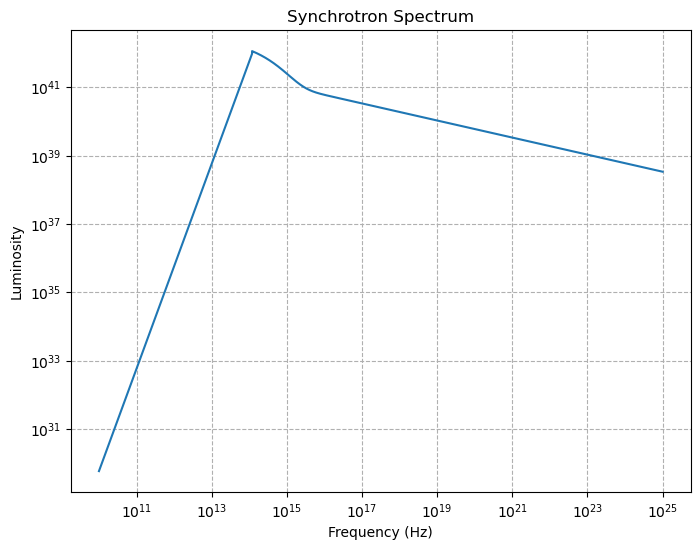

In [67]:
plt.figure(figsize=(8,6))
plt.loglog(freq_list, freq_lum_list)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Luminosity")
plt.title("Synchrotron Spectrum")

plt.grid(True, which="both", linestyle="--")
plt.show()